# MVP: Monitoramento Visual de Foco com YOLO26 e MediaPipe

**Objetivo experimental:** verificar se sinais visuais simples de um vídeo gravado: presença, celular visível e orientação aproximada da cabeça permitem estimar, de forma aproximada, períodos de foco e distração.

Este notebook não mede atenção humana cientificamente. Ele implementa um MVP auditável com heurísticas, debounce temporal, vídeo anotado e métricas finais. A sequência é propositalmente incremental:

1. validar `person` e `cell phone` com YOLO;
2. validar rosto e orientação com MediaPipe;
3. validar as regras e a máquina temporal com dados sintéticos;
4. somente então integrar e processar o vídeo completo.

> Execute as células em ordem. Não prossiga para a integração se as amostras de YOLO e orientação não fizerem sentido para o vídeo/câmera usados.


## 1 — Dependências

O notebook reaproveita **Ultralytics**, OpenCV, pandas e matplotlib. A única técnica adicional é o **MediaPipe Face Landmarker**, necessário para obter landmarks faciais sem treinamento customizado. A célula instala apenas pacotes ausentes: usa `pip` no Colab e `uv pip` quando o kernel pertence a um ambiente `uv` sem o módulo `pip`. Se o Colab solicitar reinício após a primeira instalação, reinicie a sessão e execute novamente desde esta célula.


In [1]:
import importlib.util
import subprocess
import sys
from shutil import which

DEPENDENCIAS = {
    "ultralytics": "ultralytics>=8.4.0,<9",
    "mediapipe": "mediapipe>=0.10.20,<2",
}
ausentes = [spec for modulo, spec in DEPENDENCIAS.items() if importlib.util.find_spec(modulo) is None]

def comando_instalacao(pacotes):
    if importlib.util.find_spec("pip") is not None:
        return [sys.executable, "-m", "pip", "install", *pacotes]

    uv_executable = which("uv")
    if uv_executable is not None:
        return [uv_executable, "pip", "install", "--python", sys.executable, *pacotes]

    raise RuntimeError(
        "Este kernel não possui pip e o executável uv não foi encontrado. "
        "No Colab, execute `%pip install ultralytics mediapipe` em uma célula separada."
    )

if ausentes:
    print("Instalando somente as dependências ausentes:", ", ".join(ausentes))
    comando = comando_instalacao(ausentes)
    print("Instalador selecionado:", comando[0])
    subprocess.check_call(comando)
    importlib.invalidate_caches()
else:
    print("Ultralytics e MediaPipe já estão disponíveis; nenhuma instalação foi necessária.")


Ultralytics e MediaPipe já estão disponíveis; nenhuma instalação foi necessária.


## 2 — Imports e configurações

Todos os parâmetros ajustáveis ficam abaixo. Os limiares de cabeça são **razões normalizadas pela distância entre os olhos**, não pixels:

- `HEAD_YAW_THRESHOLD = 0.18`: o nariz precisa se deslocar mais de 18% da distância entre os olhos em relação ao centro ocular;
- `HEAD_DOWN_THRESHOLD = 0.70`: a distância vertical olhos→nariz precisa superar 70% da distância entre os olhos;
- `MIRRORED_VIDEO`: inverte apenas os rótulos LEFT/RIGHT quando o arquivo foi salvo espelhado.

Esses valores são pontos de partida. A etapa 6 exibe os sinais numéricos para calibração com a câmera real. Para validar eventos conhecidos, informe até seis segundos exatos em `VALIDATION_TIMESTAMPS_SECONDS`; com `None`, o notebook amostra o vídeo uniformemente.


In [ ]:
from collections import Counter
from pathlib import Path
from shutil import which
from urllib.request import urlretrieve
import importlib.util
import math
import subprocess
import warnings

import cv2
import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np
import pandas as pd
from IPython.display import Video, display
from ultralytics import YOLO

# Desempenho e detecção
PROCESS_EVERY_N_FRAMES = 2
VALIDATION_TIMESTAMPS_SECONDS = None  # ex.: [5, 12, 18, 25] para eventos controlados
PERSON_CONFIDENCE = 0.50
PHONE_CONFIDENCE = 0.40
YOLO_IMAGE_SIZE = 640
CONVERT_OUTPUT_TO_H264 = False  # True melhora compatibilidade, mas adiciona recodificação lenta
DISPLAY_OUTPUT_INLINE = False   # Evita carregar um vídeo grande em base64 no notebook

# Caminho único de entrada. No Colab, envie o arquivo com o nome video.mp4 para /content.
INPUT_VIDEO_PATH = Path("content/video.mp4")

# Heurísticas faciais (normalizadas pela distância entre os olhos)
HEAD_YAW_THRESHOLD = 0.18
HEAD_DOWN_THRESHOLD = 0.70
MIRRORED_VIDEO = False
FACE_DETECTION_CONFIDENCE = 0.50
FACE_PRESENCE_CONFIDENCE = 0.50
FACE_TRACKING_CONFIDENCE = 0.50

# Regras temporais
DISTRACTION_MIN_SECONDS = 2.0
RECOVERY_MIN_SECONDS = 1.0
UNKNOWN_GRACE_SECONDS = 1.0

BASE_DIR = Path.cwd()
DADOS_DIR = BASE_DIR / "dados"
SAIDAS_DIR = BASE_DIR / "saidas_mvp"
DADOS_DIR.mkdir(parents=True, exist_ok=True)
SAIDAS_DIR.mkdir(parents=True, exist_ok=True)

YOLO_WEIGHTS = "yolo26n.pt"  # reaproveita a variante nano do notebook original
FACE_MODEL_PATH = DADOS_DIR / "face_landmarker.task"
FACE_MODEL_URL = (
    "https://storage.googleapis.com/mediapipe-models/face_landmarker/"
    "face_landmarker/float16/latest/face_landmarker.task"
)
RAW_OUTPUT_VIDEO_PATH = SAIDAS_DIR / "sessao_foco_anotada_opencv.mp4"
OUTPUT_VIDEO_PATH = SAIDAS_DIR / "sessao_foco_anotada.mp4"

assert PROCESS_EVERY_N_FRAMES >= 1
assert 0 <= PERSON_CONFIDENCE <= 1 and 0 <= PHONE_CONFIDENCE <= 1
print("Configuração carregada. Ajuste somente esta célula durante a calibração.")


Configuração carregada. Ajuste somente esta célula durante a calibração.


## 3 — Carregamento e teste rápido do YOLO

Mantemos `yolo26n.pt`, já usado no notebook original. O teste em uma imagem conhecida confirma que pesos e inferência funcionam antes de depender do vídeo do MVP.

**Saída esperada:** modelo carregado e uma imagem com caixas, incluindo pelo menos uma pessoa. Se esta célula falhar, corrija a instalação/modelo antes de continuar.


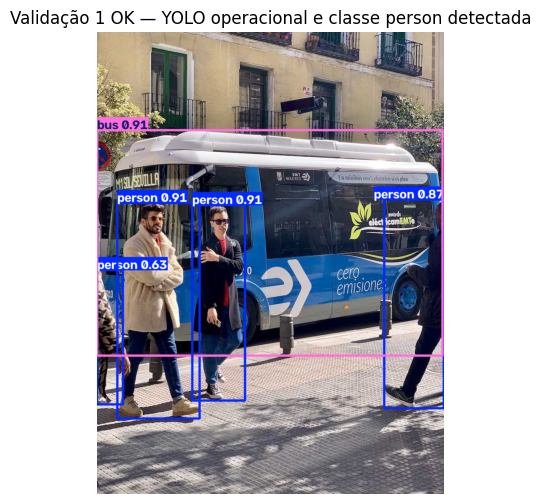

Modelo: yolo26n.pt | tarefa: detect | classes encontradas: Counter({'person': 4, 'bus': 1})


In [3]:
TEST_IMAGE_PATH = DADOS_DIR / "bus.jpg"
TEST_IMAGE_URL = "https://ultralytics.com/images/bus.jpg"
if not TEST_IMAGE_PATH.exists():
    urlretrieve(TEST_IMAGE_URL, TEST_IMAGE_PATH)

modelo = YOLO(YOLO_WEIGHTS)
resultado_teste = modelo.predict(
    str(TEST_IMAGE_PATH), conf=PERSON_CONFIDENCE, imgsz=YOLO_IMAGE_SIZE, verbose=False
)[0]

nomes_teste = []
if resultado_teste.boxes is not None:
    nomes_teste = [resultado_teste.names[int(i)] for i in resultado_teste.boxes.cls.cpu().numpy()]

assert "person" in nomes_teste, "Validação 1 falhou: YOLO não detectou person na imagem de teste."
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(resultado_teste.plot(), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Validação 1 OK — YOLO operacional e classe person detectada")
plt.show()
print("Modelo:", YOLO_WEIGHTS, "| tarefa:", modelo.task, "| classes encontradas:", Counter(nomes_teste))


## 4 — Upload e inspeção do vídeo

Envie manualmente um `.mp4` pelo painel lateral de arquivos do Colab e mantenha um único caminho: `/content/video.mp4`. A célula não abre widget, não baixa arquivos e não tenta descobrir nomes. A duração é calculada como `número de frames / FPS`, mantendo o relógio original mesmo quando pulamos inferências.

**Validação manual:** confira se resolução, FPS e duração batem aproximadamente com as propriedades do arquivo. Para a validação final, prefira um vídeo de 2–5 minutos com foco, olhada curta, olhada longa, celular, ausência e retorno.


In [10]:
VIDEO_PATH = Path(INPUT_VIDEO_PATH)
if not VIDEO_PATH.exists():
    raise FileNotFoundError(
        f"Vídeo não encontrado em {VIDEO_PATH}. No painel lateral do Colab, abra "
        "Arquivos, faça upload do MP4 e renomeie-o para video.mp4."
    )
if VIDEO_PATH.suffix.lower() != ".mp4":
    warnings.warn("O MVP foi validado para .mp4; outros contêineres podem depender de codecs do ambiente.")

captura = cv2.VideoCapture(str(VIDEO_PATH))
if not captura.isOpened():
    raise RuntimeError(f"OpenCV não conseguiu abrir {VIDEO_PATH}.")

FPS = float(captura.get(cv2.CAP_PROP_FPS))
FRAME_COUNT = int(captura.get(cv2.CAP_PROP_FRAME_COUNT))
FRAME_WIDTH = int(captura.get(cv2.CAP_PROP_FRAME_WIDTH))
FRAME_HEIGHT = int(captura.get(cv2.CAP_PROP_FRAME_HEIGHT))
captura.release()

if FPS <= 0 or FRAME_COUNT <= 0:
    raise RuntimeError("FPS ou número de frames inválido; converta o vídeo para MP4/H.264 e tente novamente.")

SESSION_DURATION = FRAME_COUNT / FPS
INSPECTED_VIDEO_PATH = VIDEO_PATH.resolve()
print(f"Arquivo:    {VIDEO_PATH}")
print(f"Resolução:  {FRAME_WIDTH} × {FRAME_HEIGHT}")
print(f"FPS:        {FPS:.3f}")
print(f"Frames:     {FRAME_COUNT:,}")
print(f"Duração:    {SESSION_DURATION:.2f}s ({SESSION_DURATION / 60:.2f} min)")
print(f"Inferência: 1 a cada {PROCESS_EVERY_N_FRAMES} frames "
      f"(~{FPS / PROCESS_EVERY_N_FRAMES:.2f} análises/s)")


FileNotFoundError: Vídeo não encontrado em /content/video.mp4. No painel lateral do Colab, abra Arquivos, faça upload do MP4 e renomeie-o para video.mp4.

## 5 — YOLO isolado no vídeo: pessoa e telefone

Esta etapa amostra quadros distribuídos pelo vídeo e filtra somente `person` e `cell phone`. Cada classe usa seu próprio limiar. O celular é um sinal visual simples: o MVP não prova que ele está sendo usado.

**Saída esperada:** caixas verdes em pessoas e vermelhas em celulares. A ausência total de `person` interrompe a validação. A ausência de celular gera um aviso: use um trecho em que o aparelho fique grande e visível por alguns segundos antes de considerar a Validação 2 aprovada.


In [ ]:
# Reconstrói os metadados se esta célula for executada isoladamente ou após trocar o vídeo.
if "VIDEO_PATH" not in globals():
    VIDEO_PATH = Path(INPUT_VIDEO_PATH)
VIDEO_PATH = Path(VIDEO_PATH)
metadados_ausentes = any(
    nome not in globals()
    for nome in ["FPS", "FRAME_COUNT", "FRAME_WIDTH", "FRAME_HEIGHT", "SESSION_DURATION"]
)
video_mudou = (
    "INSPECTED_VIDEO_PATH" not in globals()
    or Path(INSPECTED_VIDEO_PATH) != VIDEO_PATH.resolve()
)
if metadados_ausentes or video_mudou:
    if not VIDEO_PATH.exists():
        raise FileNotFoundError(f"Vídeo não encontrado: {VIDEO_PATH}")
    captura = cv2.VideoCapture(str(VIDEO_PATH))
    if not captura.isOpened():
        raise RuntimeError(f"OpenCV não conseguiu abrir {VIDEO_PATH}.")
    FPS = float(captura.get(cv2.CAP_PROP_FPS))
    FRAME_COUNT = int(captura.get(cv2.CAP_PROP_FRAME_COUNT))
    FRAME_WIDTH = int(captura.get(cv2.CAP_PROP_FRAME_WIDTH))
    FRAME_HEIGHT = int(captura.get(cv2.CAP_PROP_FRAME_HEIGHT))
    captura.release()
    if FPS <= 0 or FRAME_COUNT <= 0:
        raise RuntimeError("FPS ou número de frames inválido no vídeo.")
    SESSION_DURATION = FRAME_COUNT / FPS
    INSPECTED_VIDEO_PATH = VIDEO_PATH.resolve()
    print(
        f"Metadados reconstruídos: {FRAME_WIDTH}x{FRAME_HEIGHT}, {FPS:.3f} FPS, "
        f"{FRAME_COUNT} frames, {SESSION_DURATION:.2f}s"
    )

def class_id(nome: str) -> int:
    nomes = modelo.names
    pares = nomes.items() if hasattr(nomes, "items") else enumerate(nomes)
    for indice, rotulo in pares:
        if rotulo == nome:
            return int(indice)
    raise ValueError(f"Classe {nome!r} não existe neste modelo.")


PERSON_CLASS_ID = class_id("person")
PHONE_CLASS_ID = class_id("cell phone")


def detectar_yolo(frame_bgr: np.ndarray) -> list[dict]:
    # Retorna somente pessoas e celulares que passam pelo limiar específico da classe.
    resultado = modelo.predict(
        frame_bgr,
        conf=min(PERSON_CONFIDENCE, PHONE_CONFIDENCE),
        classes=[PERSON_CLASS_ID, PHONE_CLASS_ID],
        imgsz=YOLO_IMAGE_SIZE,
        verbose=False,
    )[0]
    deteccoes = []
    if resultado.boxes is None:
        return deteccoes

    for box, conf, cls_id in zip(
        resultado.boxes.xyxy.cpu().numpy(),
        resultado.boxes.conf.cpu().numpy(),
        resultado.boxes.cls.cpu().numpy().astype(int),
    ):
        nome = resultado.names[int(cls_id)]
        limiar = PERSON_CONFIDENCE if nome == "person" else PHONE_CONFIDENCE
        if float(conf) >= limiar:
            deteccoes.append(
                {"class_name": nome, "confidence": float(conf), "box": tuple(map(int, box))}
            )
    return deteccoes


def ler_frame_no_tempo(video_path: Path, segundo: float) -> np.ndarray:
    cap = cv2.VideoCapture(str(video_path))
    cap.set(cv2.CAP_PROP_POS_MSEC, max(0.0, segundo) * 1000)
    ok, frame = cap.read()
    cap.release()
    if not ok:
        raise RuntimeError(f"Não foi possível ler o frame em {segundo:.2f}s.")
    return frame


def desenhar_deteccoes(frame: np.ndarray, deteccoes: list[dict]) -> np.ndarray:
    saida = frame.copy()
    for det in deteccoes:
        x1, y1, x2, y2 = det["box"]
        cor = (50, 205, 50) if det["class_name"] == "person" else (50, 50, 235)
        cv2.rectangle(saida, (x1, y1), (x2, y2), cor, 2)
        texto = f'{det["class_name"]} {det["confidence"]:.2f}'
        cv2.putText(saida, texto, (x1, max(22, y1 - 7)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, cor, 2)
    return saida


if VALIDATION_TIMESTAMPS_SECONDS is None:
    tempos_amostra = np.linspace(0, max(0, SESSION_DURATION - 1 / FPS), num=min(6, FRAME_COUNT))
else:
    tempos_amostra = np.array(VALIDATION_TIMESTAMPS_SECONDS, dtype=float)
    if not 1 <= len(tempos_amostra) <= 6:
        raise ValueError("Use entre 1 e 6 tempos de validação.")
    if np.any((tempos_amostra < 0) | (tempos_amostra >= SESSION_DURATION)):
        raise ValueError("Todos os tempos de validação devem estar dentro da duração do vídeo.")
registros_yolo = []
fig, eixos = plt.subplots(2, 3, figsize=(16, 9))
for eixo, tempo in zip(eixos.flat, tempos_amostra):
    frame = ler_frame_no_tempo(VIDEO_PATH, float(tempo))
    deteccoes = detectar_yolo(frame)
    classes = [d["class_name"] for d in deteccoes]
    registros_yolo.append(
        {"time_s": round(float(tempo), 2), "person": classes.count("person"),
         "cell_phone": classes.count("cell phone")}
    )
    eixo.imshow(cv2.cvtColor(desenhar_deteccoes(frame, deteccoes), cv2.COLOR_BGR2RGB))
    eixo.set_title(f"t={tempo:.1f}s | {Counter(classes)}")
    eixo.axis("off")
for eixo in eixos.flat[len(tempos_amostra):]:
    eixo.axis("off")
plt.tight_layout()
plt.show()

validacao_yolo_df = pd.DataFrame(registros_yolo)
display(validacao_yolo_df)
if validacao_yolo_df["person"].sum() == 0:
    raise RuntimeError("Validação 1 falhou no vídeo: nenhuma pessoa foi detectada nas amostras.")
print("✓ Validação 1: person aparece nas amostras.")
if validacao_yolo_df["cell_phone"].sum() == 0:
    print("⚠ Validação 2 pendente: nenhum celular nas amostras. Teste um trecho propositalmente visível.")
else:
    print("✓ Validação 2: cell phone foi detectado em pelo menos uma amostra.")


## 6 — Face e orientação da cabeça isoladas

O Face Landmarker é aplicado apenas ao recorte da **maior pessoa**, assumida como estudante. A geometria usa olhos (landmarks 33/263) e ponta do nariz (1):

- `yaw_signal = (nariz_x − centro_dos_olhos_x) / distância_entre_os_olhos`;
- `down_signal = (nariz_y − linha_dos_olhos_y) / distância_entre_os_olhos`.

Primeiro verificamos `DOWN`; depois `LEFT/RIGHT`; caso contrário, `CENTER`. Sem rosto confiável, o resultado é `UNKNOWN`. Os rótulos laterais representam a direção da própria pessoa em vídeo não espelhado.

**Validação manual:** escolha/produza frames olhando ao centro, à esquerda, à direita e para baixo. Confira rótulo e sinais numéricos. Ajuste exclusivamente os thresholds da célula 2. Iluminação frontal e rosto com pelo menos ~100 px de largura ajudam bastante.


In [ ]:
if not FACE_MODEL_PATH.exists():
    print("Baixando o modelo pré-treinado Face Landmarker...")
    urlretrieve(FACE_MODEL_URL, FACE_MODEL_PATH)


def criar_face_landmarker(running_mode):
    options = mp.tasks.vision.FaceLandmarkerOptions(
        base_options=mp.tasks.BaseOptions(model_asset_path=str(FACE_MODEL_PATH)),
        running_mode=running_mode,
        num_faces=1,
        min_face_detection_confidence=FACE_DETECTION_CONFIDENCE,
        min_face_presence_confidence=FACE_PRESENCE_CONFIDENCE,
        min_tracking_confidence=FACE_TRACKING_CONFIDENCE,
    )
    return mp.tasks.vision.FaceLandmarker.create_from_options(options)


def maior_pessoa(deteccoes: list[dict]):
    pessoas = [d for d in deteccoes if d["class_name"] == "person"]
    if not pessoas:
        return None
    return max(pessoas, key=lambda d: (d["box"][2] - d["box"][0]) * (d["box"][3] - d["box"][1]))


def recorte_expandido(frame: np.ndarray, box: tuple[int, int, int, int], margem=0.05):
    h, w = frame.shape[:2]
    x1, y1, x2, y2 = box
    dx, dy = int((x2 - x1) * margem), int((y2 - y1) * margem)
    x1, y1 = max(0, x1 - dx), max(0, y1 - dy)
    x2, y2 = min(w, x2 + dx), min(h, y2 + dy)
    return frame[y1:y2, x1:x2], (x1, y1, x2, y2)


def analisar_cabeca(frame_bgr, person_box, landmarker, timestamp_ms=None) -> dict:
    desconhecido = {
        "face_detected": False, "orientation": "UNKNOWN",
        "yaw_signal": math.nan, "down_signal": math.nan,
        "face_box": None, "points": {},
    }
    if person_box is None:
        return desconhecido

    crop, (cx1, cy1, cx2, cy2) = recorte_expandido(frame_bgr, person_box)
    if crop.size == 0:
        return desconhecido
    rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    if timestamp_ms is None:
        result = landmarker.detect(mp_image)
    else:
        result = landmarker.detect_for_video(mp_image, int(timestamp_ms))
    if not result.face_landmarks:
        return desconhecido

    lm = result.face_landmarks[0]
    eye_a, eye_b, nose = lm[33], lm[263], lm[1]
    eye_dx, eye_dy = eye_b.x - eye_a.x, eye_b.y - eye_a.y
    eye_distance = math.hypot(eye_dx, eye_dy)
    if eye_distance < 1e-6:
        return desconhecido

    eye_mid_x = (eye_a.x + eye_b.x) / 2
    eye_mid_y = (eye_a.y + eye_b.y) / 2
    yaw_signal = (nose.x - eye_mid_x) / eye_distance
    if MIRRORED_VIDEO:
        yaw_signal *= -1
    down_signal = (nose.y - eye_mid_y) / eye_distance

    if down_signal > HEAD_DOWN_THRESHOLD:
        orientation = "DOWN"
    elif yaw_signal > HEAD_YAW_THRESHOLD:
        orientation = "LEFT"
    elif yaw_signal < -HEAD_YAW_THRESHOLD:
        orientation = "RIGHT"
    else:
        orientation = "CENTER"

    crop_h, crop_w = crop.shape[:2]
    xs = np.array([p.x for p in lm])
    ys = np.array([p.y for p in lm])
    face_box = (
        cx1 + int(np.clip(xs.min(), 0, 1) * crop_w),
        cy1 + int(np.clip(ys.min(), 0, 1) * crop_h),
        cx1 + int(np.clip(xs.max(), 0, 1) * crop_w),
        cy1 + int(np.clip(ys.max(), 0, 1) * crop_h),
    )
    points = {
        "eye_a": (cx1 + int(eye_a.x * crop_w), cy1 + int(eye_a.y * crop_h)),
        "eye_b": (cx1 + int(eye_b.x * crop_w), cy1 + int(eye_b.y * crop_h)),
        "nose": (cx1 + int(nose.x * crop_w), cy1 + int(nose.y * crop_h)),
    }
    return {
        "face_detected": True, "orientation": orientation,
        "yaw_signal": float(yaw_signal), "down_signal": float(down_signal),
        "face_box": face_box, "points": points,
    }


def desenhar_cabeca(frame: np.ndarray, head: dict) -> np.ndarray:
    saida = frame.copy()
    if head["face_box"] is not None:
        x1, y1, x2, y2 = head["face_box"]
        cv2.rectangle(saida, (x1, y1), (x2, y2), (255, 190, 0), 2)
        for ponto in head["points"].values():
            cv2.circle(saida, ponto, 4, (255, 255, 0), -1)
    return saida


registros_face = []
fig, eixos = plt.subplots(2, 3, figsize=(16, 9))
with criar_face_landmarker(mp.tasks.vision.RunningMode.IMAGE) as landmarker_imagem:
    for eixo, tempo in zip(eixos.flat, tempos_amostra):
        frame = ler_frame_no_tempo(VIDEO_PATH, float(tempo))
        deteccoes = detectar_yolo(frame)
        pessoa = maior_pessoa(deteccoes)
        head = analisar_cabeca(frame, None if pessoa is None else pessoa["box"], landmarker_imagem)
        registros_face.append(
            {"time_s": round(float(tempo), 2), "orientation": head["orientation"],
             "yaw_signal": round(head["yaw_signal"], 3),
             "down_signal": round(head["down_signal"], 3)}
        )
        amostra = desenhar_cabeca(desenhar_deteccoes(frame, deteccoes), head)
        eixo.imshow(cv2.cvtColor(amostra, cv2.COLOR_BGR2RGB))
        eixo.set_title(
            f't={tempo:.1f}s | {head["orientation"]}\n'
            f'yaw={head["yaw_signal"]:.2f} down={head["down_signal"]:.2f}'
        )
        eixo.axis("off")
for eixo in eixos.flat[len(tempos_amostra):]:
    eixo.axis("off")
plt.tight_layout()
plt.show()

validacao_face_df = pd.DataFrame(registros_face)
display(validacao_face_df)
if (validacao_face_df["orientation"] == "UNKNOWN").all():
    raise RuntimeError("Validação facial falhou: nenhum rosto foi detectado nas amostras.")
print("✓ Face Landmarker operacional. A aprovação de CENTER/LEFT/RIGHT/DOWN exige inspeção manual.")


## 7 — Classificação explícita do estado bruto

Prioridade aplicada: **ABSENT → PHONE → LOOKING_AWAY → FOCUSED → UNKNOWN**. `laptop` e `book` não alteram o estado. Um rosto ausente apesar de uma pessoa detectada vira `UNKNOWN`, pois não há evidência suficiente para declarar foco.

**Validação manual:** os exemplos sintéticos abaixo devem cobrir todas as regras sem executar visão computacional.


In [ ]:
def classify_state(person_present: bool, phone_present: bool, head_orientation: str) -> dict:
    # Classifica um frame analisado seguindo a prioridade documentada.
    if not person_present:
        return {"state": "ABSENT", "reason": "absent"}
    if phone_present:
        return {"state": "DISTRACTED", "reason": "phone"}
    if head_orientation == "LEFT":
        return {"state": "DISTRACTED", "reason": "looking_left"}
    if head_orientation == "RIGHT":
        return {"state": "DISTRACTED", "reason": "looking_right"}
    if head_orientation == "DOWN":
        return {"state": "DISTRACTED", "reason": "looking_down"}
    if head_orientation == "CENTER":
        return {"state": "FOCUSED", "reason": "focused"}
    return {"state": "UNKNOWN", "reason": "unknown"}


casos_regra = [
    (False, False, "UNKNOWN", "ABSENT"),
    (True, True, "CENTER", "DISTRACTED"),
    (True, False, "LEFT", "DISTRACTED"),
    (True, False, "CENTER", "FOCUSED"),
    (True, False, "UNKNOWN", "UNKNOWN"),
]
for pessoa, telefone, cabeca, esperado in casos_regra:
    obtido = classify_state(pessoa, telefone, cabeca)
    assert obtido["state"] == esperado, (pessoa, telefone, cabeca, obtido)
print("✓ Prioridade e cinco caminhos da função classify_state validados.")


## 8 — Máquina de estados temporal

Um sinal de distração precisa persistir por `DISTRACTION_MIN_SECONDS`; o retorno ao foco precisa persistir por `RECOVERY_MIN_SECONDS`. Quando confirmado, o trecho candidato é reclassificado desde seu início, evitando perder os primeiros 2 segundos. Mudanças de motivo durante o mesmo episódio não criam novos episódios; escolhemos o motivo predominante, usando a prioridade explícita em empates.

`ABSENT` permanece um estado próprio na timeline, mas é um episódio e conta como tempo distraído. `UNKNOWN` é tolerado por `UNKNOWN_GRACE_SECONDS` e, se persistir, fica fora de `total_valid_time` — ele não é convertido artificialmente em foco ou distração.


In [ ]:
REASON_PRIORITY = ["absent", "phone", "looking_left", "looking_right", "looking_down", "unknown"]


class TemporalStateMachine:
    def __init__(self):
        self.timeline = []
        self.episodes = []
        self.current_state = "UNKNOWN"
        self.in_episode = False
        self.distraction_candidate = None
        self.focus_candidate = None
        self.unknown_candidate = None
        self.active_episode = None
        self.distraction_count = 0

    @staticmethod
    def _dominant_reason(counts: Counter) -> str:
        if not counts:
            return "unknown"
        priority = {reason: len(REASON_PRIORITY) - i for i, reason in enumerate(REASON_PRIORITY)}
        return max(counts, key=lambda r: (counts[r], priority.get(r, 0)))

    def _retag_distraction(self, start_index: int):
        for row in self.timeline[start_index:]:
            if row["raw_state"] in {"DISTRACTED", "ABSENT"}:
                row["state"] = row["raw_state"]
                row["reason"] = row["raw_reason"]

    def _close_episode(self, end_time: float):
        start = self.active_episode["start"]
        reason = self._dominant_reason(self.active_episode["reason_counts"])
        self.episodes.append(
            {"start": start, "end": end_time, "duration": max(0.0, end_time - start),
             "reason": reason}
        )
        self.active_episode = None

    def update(self, timestamp: float, raw_state: str, raw_reason: str) -> dict:
        if self.timeline and timestamp <= self.timeline[-1]["timestamp"]:
            raise ValueError("Os timestamps precisam ser estritamente crescentes.")
        self.timeline.append(
            {"timestamp": float(timestamp), "raw_state": raw_state, "raw_reason": raw_reason,
             "state": self.current_state, "reason": "unknown"}
        )
        idx = len(self.timeline) - 1
        row = self.timeline[idx]

        if self.in_episode:
            if raw_state == "FOCUSED":
                if self.focus_candidate is None:
                    self.focus_candidate = {"start": timestamp, "index": idx}
                if timestamp - self.focus_candidate["start"] >= RECOVERY_MIN_SECONDS:
                    for item in self.timeline[self.focus_candidate["index"]:]:
                        item["state"], item["reason"] = "FOCUSED", "focused"
                    self._close_episode(self.focus_candidate["start"])
                    self.in_episode = False
                    self.current_state = "FOCUSED"
                    self.focus_candidate = None
                else:
                    row["state"] = self.current_state
                    row["reason"] = self._dominant_reason(self.active_episode["reason_counts"])
            elif raw_state in {"DISTRACTED", "ABSENT"}:
                self.focus_candidate = None
                self.current_state = raw_state
                row["state"], row["reason"] = raw_state, raw_reason
                self.active_episode["reason_counts"][raw_reason] += 1
            else:
                self.focus_candidate = None
                row["state"] = self.current_state
                row["reason"] = self._dominant_reason(self.active_episode["reason_counts"])
            return row

        if raw_state == "FOCUSED":
            self.distraction_candidate = None
            self.unknown_candidate = None
            self.current_state = "FOCUSED"
            row["state"], row["reason"] = "FOCUSED", "focused"
        elif raw_state in {"DISTRACTED", "ABSENT"}:
            self.unknown_candidate = None
            if self.distraction_candidate is None:
                self.distraction_candidate = {
                    "start": timestamp, "index": idx, "reason_counts": Counter()
                }
            self.distraction_candidate["reason_counts"][raw_reason] += 1
            if timestamp - self.distraction_candidate["start"] >= DISTRACTION_MIN_SECONDS:
                self._retag_distraction(self.distraction_candidate["index"])
                self.in_episode = True
                self.current_state = raw_state
                self.active_episode = {
                    "start": self.distraction_candidate["start"],
                    "reason_counts": self.distraction_candidate["reason_counts"].copy(),
                }
                self.distraction_candidate = None
                self.distraction_count += 1
        else:
            self.distraction_candidate = None
            if self.unknown_candidate is None:
                self.unknown_candidate = {"start": timestamp, "index": idx}
            if timestamp - self.unknown_candidate["start"] >= UNKNOWN_GRACE_SECONDS:
                for item in self.timeline[self.unknown_candidate["index"]:]:
                    item["state"], item["reason"] = "UNKNOWN", "unknown"
                self.current_state = "UNKNOWN"
        return row

    def finalize(self, video_duration: float):
        if self.in_episode:
            self._close_episode(video_duration)
            self.in_episode = False
        if self.unknown_candidate is not None:
            if video_duration - self.unknown_candidate["start"] >= UNKNOWN_GRACE_SECONDS:
                for item in self.timeline[self.unknown_candidate["index"]:]:
                    item["state"], item["reason"] = "UNKNOWN", "unknown"
        return self.metrics(video_duration)

    def metrics(self, end_time: float) -> dict:
        durations = Counter()
        for i, row in enumerate(self.timeline):
            interval_end = self.timeline[i + 1]["timestamp"] if i + 1 < len(self.timeline) else end_time
            durations[row["state"]] += max(0.0, interval_end - row["timestamp"])
        focused = durations["FOCUSED"]
        absent = durations["ABSENT"]
        distracted = durations["DISTRACTED"] + absent
        unknown = durations["UNKNOWN"]
        valid = focused + distracted
        focus_score = 100 * focused / valid if valid > 0 else 0.0
        episode_durations = [e["duration"] for e in self.episodes]
        return {
            "session_duration": end_time,
            "total_valid_time": valid,
            "focused_time": focused,
            "distracted_time": distracted,
            "absent_time": absent,
            "unknown_time": unknown,
            "focus_score": focus_score,
            "distraction_count": self.distraction_count,
            "longest_distraction": max(episode_durations, default=0.0),
            "average_distraction": (
                sum(episode_durations) / len(episode_durations) if episode_durations else 0.0
            ),
        }


### Validação temporal determinística

Este teste não depende do vídeo: uma distração de 1,5 s deve ser ignorada; outra de 2,5 s deve produzir exatamente um episódio. Também validamos ausência sustentada separadamente.


In [ ]:
def alimentar(maquina, inicio, duracao, state, reason, passo=0.25):
    for t in np.arange(inicio, inicio + duracao, passo):
        maquina.update(float(round(t, 6)), state, reason)


teste = TemporalStateMachine()
alimentar(teste, 0.00, 1.00, "FOCUSED", "focused")
alimentar(teste, 1.00, 1.50, "DISTRACTED", "looking_left")  # curta
alimentar(teste, 2.50, 1.25, "FOCUSED", "focused")
alimentar(teste, 3.75, 2.50, "DISTRACTED", "phone")         # longa
alimentar(teste, 6.25, 1.50, "FOCUSED", "focused")
metricas_teste = teste.finalize(7.75)

assert metricas_teste["distraction_count"] == 1, teste.episodes
assert len(teste.episodes) == 1 and teste.episodes[0]["reason"] == "phone"
assert abs(teste.episodes[0]["duration"] - 2.5) < 0.01

teste_ausencia = TemporalStateMachine()
alimentar(teste_ausencia, 0.0, 1.0, "FOCUSED", "focused")
alimentar(teste_ausencia, 1.0, 2.5, "ABSENT", "absent")
metricas_ausencia = teste_ausencia.finalize(3.5)
assert metricas_ausencia["distraction_count"] == 1
assert metricas_ausencia["absent_time"] > 0

print("✓ Validação 5: distração curta ignorada; distração longa gera exatamente um episódio.")
print("✓ Validação 6 (lógica): ausência sustentada mantém estado ABSENT e gera um episódio.")
display(pd.DataFrame(teste.episodes))


## 9 — Processamento completo e vídeo anotado

Em cada frame selecionado executamos YOLO, Face Landmarker, regra bruta e máquina temporal. Frames intermediários reutilizam a última anotação, mas são todos gravados; portanto o vídeo de saída mantém FPS e duração originais. O tempo de cada amostra usa `frame_index / FPS`, não o número de inferências.

**Saída esperada:** progresso até 100%, um `.mp4` em `saidas_mvp/` e métricas coerentes. Em CPU, aumente `PROCESS_EVERY_N_FRAMES` para 3–5; em GPU, 2 costuma ser um ponto de partida simples.


In [ ]:
STATE_COLORS = {
    "FOCUSED": (40, 190, 40),
    "DISTRACTED": (30, 40, 230),
    "ABSENT": (0, 140, 255),
    "UNKNOWN": (150, 150, 150),
}


def annotate_frame(frame, detections, head, temporal_row, raw_result, partial_metrics, elapsed):
    out = desenhar_deteccoes(frame, detections)
    out = desenhar_cabeca(out, head)
    state = temporal_row["state"]
    color = STATE_COLORS[state]

    overlay = out.copy()
    cv2.rectangle(overlay, (12, 12), (465, 190), (15, 15, 15), -1)
    cv2.addWeighted(overlay, 0.70, out, 0.30, 0, out)
    lines = [
        (f"STATUS: {state}", color),
        (f'HEAD: {head["orientation"]}', (240, 240, 240)),
        (f'TIME: {elapsed:7.1f}s', (240, 240, 240)),
        (f'FOCUS: {partial_metrics["focus_score"]:5.1f}% ', (240, 240, 240)),
        (f'DISTRACTIONS: {partial_metrics["distraction_count"]}', (240, 240, 240)),
        (f'RAW: {raw_result["reason"]}', (210, 210, 210)),
    ]
    for i, (text, line_color) in enumerate(lines):
        cv2.putText(out, text, (26, 42 + i * 27), cv2.FONT_HERSHEY_SIMPLEX,
                    0.68, line_color, 2, cv2.LINE_AA)
    return out


cap = cv2.VideoCapture(str(VIDEO_PATH))
if not cap.isOpened():
    raise RuntimeError(f"Não foi possível reabrir {VIDEO_PATH}.")
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(str(RAW_OUTPUT_VIDEO_PATH), fourcc, FPS, (FRAME_WIDTH, FRAME_HEIGHT))
if not writer.isOpened():
    cap.release()
    raise RuntimeError("Não foi possível criar o vídeo MP4. Verifique suporte ao codec mp4v.")

machine = TemporalStateMachine()
last_detections = []
last_head = {"face_detected": False, "orientation": "UNKNOWN", "yaw_signal": math.nan,
             "down_signal": math.nan, "face_box": None, "points": {}}
last_raw = {"state": "UNKNOWN", "reason": "unknown"}
last_row = {"state": "UNKNOWN", "reason": "unknown"}
last_partial = {"focus_score": 0.0, "distraction_count": 0}
frames_lidos = 0
analyses = 0
proximo_progresso = 10

landmarker_video = criar_face_landmarker(mp.tasks.vision.RunningMode.VIDEO)
try:
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        timestamp = frames_lidos / FPS

        if frames_lidos % PROCESS_EVERY_N_FRAMES == 0:
            analyses += 1
            last_detections = detectar_yolo(frame)
            person = maior_pessoa(last_detections)
            person_present = person is not None
            phone_present = any(d["class_name"] == "cell phone" for d in last_detections)
            last_head = analisar_cabeca(
                frame,
                None if person is None else person["box"],
                landmarker_video,
                timestamp_ms=round(timestamp * 1000),
            )
            last_raw = classify_state(person_present, phone_present, last_head["orientation"])
            last_row = machine.update(timestamp, last_raw["state"], last_raw["reason"])
            partial_end = min(SESSION_DURATION, timestamp + PROCESS_EVERY_N_FRAMES / FPS)
            last_partial = machine.metrics(partial_end)

        annotated = annotate_frame(
            frame, last_detections, last_head, last_row, last_raw, last_partial, timestamp
        )
        writer.write(annotated)
        frames_lidos += 1

        progresso = 100 * frames_lidos / max(FRAME_COUNT, 1)
        if progresso >= proximo_progresso:
            print(f"Processamento: {min(100, proximo_progresso)}%")
            proximo_progresso += 10
finally:
    print("Finalizando e fechando o vídeo OpenCV...")
    landmarker_video.close()
    cap.release()
    writer.release()

if frames_lidos == 0:
    raise RuntimeError("Nenhum frame foi processado.")
print("Calculando métricas finais...")
ANALYZED_DURATION = frames_lidos / FPS
FINAL_METRICS = machine.finalize(ANALYZED_DURATION)
EPISODES = machine.episodes
TIMELINE = machine.timeline

# O OpenCV grava mp4v de forma portátil. No Colab, o ffmpeg já disponível converte
# para H.264/yuv420p, combinação mais compatível com o player do navegador.
FINAL_VIDEO_PATH = RAW_OUTPUT_VIDEO_PATH
if CONVERT_OUTPUT_TO_H264 and which("ffmpeg"):
    print("Convertendo a saída para H.264; esta etapa pode levar alguns minutos...")
    conversao = subprocess.run(
        ["ffmpeg", "-y", "-loglevel", "warning", "-stats",
         "-i", str(RAW_OUTPUT_VIDEO_PATH), "-an", "-c:v", "libx264",
         "-preset", "veryfast", "-crf", "23", "-pix_fmt", "yuv420p",
         "-movflags", "+faststart",
         str(OUTPUT_VIDEO_PATH)],
    )
    if conversao.returncode == 0 and OUTPUT_VIDEO_PATH.exists():
        FINAL_VIDEO_PATH = OUTPUT_VIDEO_PATH
    else:
        print("⚠ Conversão H.264 indisponível; mantendo a saída mp4v do OpenCV.")
elif CONVERT_OUTPUT_TO_H264:
    print("⚠ ffmpeg não encontrado; mantendo a saída mp4v do OpenCV.")
else:
    print("Conversão H.264 ignorada por configuração; usando a saída mp4v pronta.")

print(f"✓ Vídeo completo: {frames_lidos:,} frames escritos, {analyses:,} analisados por visão.")
print(f"✓ Saída: {FINAL_VIDEO_PATH} ({FINAL_VIDEO_PATH.stat().st_size / 1e6:.1f} MB)")
if DISPLAY_OUTPUT_INLINE:
    display(Video(str(FINAL_VIDEO_PATH), embed=True, width=800))
else:
    print("Visualização inline desativada. Baixe FINAL_VIDEO_PATH ao terminar.")


## 10 — Relatório final

`Distracted Time` inclui `Absent Time`; por isso ausência é exibida como subconjunto e não deve ser somada novamente. `Unknown Time` é excluído de `Total Valid Time`. Assim:

`focus_score = focused_time / total_valid_time × 100`

**Validação manual:** confirme que duração da sessão ≈ vídeo de saída, score está entre 0 e 100, episódios não se fragmentam e os timestamps batem com eventos observáveis no vídeo.


In [ ]:
def format_duration(seconds: float) -> str:
    minutes, secs = divmod(max(0.0, seconds), 60)
    hours, minutes = divmod(int(minutes), 60)
    if hours:
        return f"{hours:d}h {minutes:02d}m {secs:04.1f}s"
    return f"{minutes:02d}m {secs:04.1f}s"


m = FINAL_METRICS
assert 0.0 <= m["focus_score"] <= 100.0
assert abs((m["focused_time"] + m["distracted_time"]) - m["total_valid_time"]) < 1e-6

print(f'Session Duration:       {format_duration(m["session_duration"])}')
print(f'Total Valid Time:       {format_duration(m["total_valid_time"])}')
print(f'Focused Time:           {format_duration(m["focused_time"])}')
print(f'Distracted Time*:       {format_duration(m["distracted_time"])}')
print(f'  of which Absent:      {format_duration(m["absent_time"])}')
print(f'Unknown Time:           {format_duration(m["unknown_time"])}')
print(f'Focus Score:            {m["focus_score"]:6.1f}%')
print()
print(f'Number of Distractions: {m["distraction_count"]:6d}')
print(f'Longest Distraction:    {m["longest_distraction"]:6.1f}s')
print(f'Average Distraction:    {m["average_distraction"]:6.1f}s')
print("\n* Distracted Time já inclui Absent Time.")

episodes_df = pd.DataFrame(EPISODES, columns=["start", "end", "duration", "reason"])
if not episodes_df.empty:
    episodes_df[["start", "end", "duration"]] = episodes_df[["start", "end", "duration"]].round(2)
display(episodes_df)

reason_counts = Counter(e["reason"] for e in EPISODES)
reasons_df = pd.DataFrame(
    [{"reason": reason, "episodes": reason_counts.get(reason, 0)} for reason in REASON_PRIORITY]
)
display(reasons_df)


## 11 — Gráficos simples

O primeiro gráfico compara somente tempo válido focado e distraído. A timeline mostra também ausência e trechos desconhecidos para tornar falhas de detecção visíveis, sem dashboard.


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), gridspec_kw={"height_ratios": [2, 1]})

labels = ["Focused", "Distracted (inclui absent)"]
values = [FINAL_METRICS["focused_time"], FINAL_METRICS["distracted_time"]]
colors = ["#35a853", "#d93025"]
bars = axes[0].bar(labels, values, color=colors)
axes[0].bar_label(bars, labels=[format_duration(v) for v in values], padding=3)
axes[0].set_ylabel("segundos")
axes[0].set_title(f'Tempo válido | Focus score = {FINAL_METRICS["focus_score"]:.1f}%')

timeline_colors = {
    "FOCUSED": "#35a853", "DISTRACTED": "#d93025",
    "ABSENT": "#f9ab00", "UNKNOWN": "#9aa0a6",
}
segments = []
if TIMELINE:
    segment_start = TIMELINE[0]["timestamp"]
    segment_state = TIMELINE[0]["state"]
    for row in TIMELINE[1:]:
        if row["state"] != segment_state:
            segments.append((segment_start, row["timestamp"] - segment_start, segment_state))
            segment_start, segment_state = row["timestamp"], row["state"]
    segments.append((segment_start, ANALYZED_DURATION - segment_start, segment_state))

for start, duration, state in segments:
    axes[1].broken_barh([(start, duration)], (0, 1), facecolors=timeline_colors[state])
axes[1].set_xlim(0, ANALYZED_DURATION)
axes[1].set_ylim(0, 1)
axes[1].set_yticks([])
axes[1].set_xlabel("tempo (s)")
axes[1].set_title("Timeline temporal confirmada")
handles = [plt.Line2D([0], [0], color=color, lw=8, label=state)
           for state, color in timeline_colors.items()]
axes[1].legend(handles=handles, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.35))

plt.tight_layout()
plt.show()


## Checklist de aceite e protocolo da sessão final

Execute uma sessão curta controlada (2–5 min) e registre manualmente os tempos aproximados de cada ação:

| Validação | Ação | Critério objetivo |
|---|---|---|
| 1 — YOLO/person | permanecer visível | `person` nas amostras e na maior parte do vídeo adequado |
| 2 — telefone | exibir o aparelho por >2 s | caixa `cell phone` e um episódio `phone` |
| 3 — centro | olhar para a tela | `CENTER` na maioria das amostras desse trecho |
| 4 — lateral | olhar esquerda/direita por >2 s | rótulo muda e episódio `looking_left/right` |
| 5 — temporal | desviar <2 s e depois >2 s | primeiro não conta; segundo conta exatamente uma vez |
| 6 — ausência | sair por >2 s | timeline `ABSENT` e episódio `absent` |
| 7 — completa | realizar todos os eventos | vídeo termina sem erro, métricas e timestamps plausíveis |

O MVP é aceito quando os 13 critérios propostos são observados no vídeo controlado. Se telefone ou orientação falharem, registre o falso negativo e ajuste apenas confiança/thresholds com base nas tabelas de amostra. Não introduza treinamento, eye tracking, backend ou outra expansão nesta etapa.

**Interpretação final:** o experimento sustenta a hipótese apenas se os eventos controlados forem separados aproximadamente e o tempo agregado fizer sentido por inspeção manual. O resultado continua sendo uma heurística visual, não uma medida psicológica de atenção.
